# Vertex-Level Error Analysis: Query vs. Interpolated, Buckets, Hotspots

Per-vertex breakdown of model error, complementing the protein-level
`error_clustering_analysis.ipynb`. Data comes from
`scripts/compute_vertex_error_stats.py`'s cached outputs — this notebook
never re-runs the RBF full-mesh reconstruction itself (a ~15-20 minute
computation across 848 proteins x 2 champions, run once and cached).

**Covers:**
- Where model error concentrates across the true-ESP range (extreme
  charge vs. near-neutral) — the "bucket" ladder-comparison style reused
  from `range_delta_breakdown`.
- Whether direct model predictions (query nodes, ~5% of the mesh) are
  meaningfully more accurate than RBF-interpolated reconstruction at the
  rest of the surface.
- Whether high-error proteins fail uniformly across their whole surface,
  or have localized error "hotspots" — using Moran's I spatial
  autocorrelation.

**Scope:** the two full-dataset champions (`attention_aa4_aq2_qq16`,
`distance_aa8_aq2_qq24`), restricted to the 848-protein test split, same
as `error_clustering_analysis.ipynb`. AlphaFold-confidence fields remain
out of scope (deferred to a future notebook).


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.insert(0, str(Path("..").resolve()))

THESIS_ROOT = Path("/home/student/thesis")
RANGE_ORDER = ["[-15, -8)", "[-8, -2)", "[-2, 2)", "[2, 8)", "[8, 15)"]


---
## 1. Load Cached Outputs

In [2]:
master  = pd.read_csv("/home/student/thesis/outputs/protein_master_dataset.csv")
vertex  = pd.read_csv("/home/student/thesis/outputs/vertex_error_dataset.csv")
buckets = pd.read_csv("/home/student/thesis/outputs/vertex_error_buckets.csv")
examples_index = pd.read_csv("/home/student/thesis/outputs/vertex_examples/example_index.csv")

print(f"vertex_error_dataset: {len(vertex):,} rows")
print(f"vertex_error_buckets: {len(buckets):,} rows")
print(f"example proteins: {len(examples_index):,}")

df_test = master[master["split"] == "test"].merge(vertex, on="protein_id", how="left")
assert len(df_test) == 848, f"Expected 848 test proteins, got {len(df_test)}"
df_test.info()


vertex_error_dataset: 848 rows
vertex_error_buckets: 20 rows
example proteins: 10
<class 'pandas.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 70 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   protein_id                    848 non-null    str    
 1   uniprot_id                    848 non-null    str    
 2   protein_name                  848 non-null    str    
 3   organism                      848 non-null    str    
 4   split                         848 non-null    str    
 5   sequence_length               848 non-null    int64  
 6   n_heavy_atoms                 848 non-null    int64  
 7   net_charge                    848 non-null    float64
 8   ses_area                      848 non-null    float64
 9   n_vertices                    848 non-null    int64  
 10  n_query_nodes                 848 non-null    int64  
 11  interp_pearson_r              848 non-null    float6

In [3]:
# Correctness cross-check: query_rmse (this notebook's own data source) should
# match attention_rmse/distance_rmse (trainer.py's independently-computed metric,
# already in the master CSV) -- validates the whole query/interpolated split.
for prefix in ("attention", "distance"):
    diff = (df_test[f"{prefix}_query_rmse"] - df_test[f"{prefix}_rmse"]).abs()
    print(f"{prefix}: max |query_rmse - rmse| = {diff.max():.2e}  (all within 1e-3: {(diff < 1e-3).all()})")
    assert (diff < 1e-3).all(), f"{prefix} query_rmse doesn't match the existing rmse metric"

for prefix in ("attention", "distance"):
    match = (df_test[f"{prefix}_n_query"] == df_test["n_query_nodes"]).all()
    print(f"{prefix}: n_query == n_query_nodes exactly: {match}")
    assert match


attention: max |query_rmse - rmse| = 4.42e-07  (all within 1e-3: True)
distance: max |query_rmse - rmse| = 4.52e-07  (all within 1e-3: True)
attention: n_query == n_query_nodes exactly: True
distance: n_query == n_query_nodes exactly: True


---
## 2. Bucket Table -- Where Does Error Concentrate Across the ESP Range?

Same named true-ESP ranges `range_delta_breakdown` uses throughout the
`decisions/` notebooks, but here summarizing one population's own |error|
at a time (via the new `pooled_bucket_table`) rather than comparing two
systems -- query-node vs. interpolated-vertex error, side by side across
the charge range.

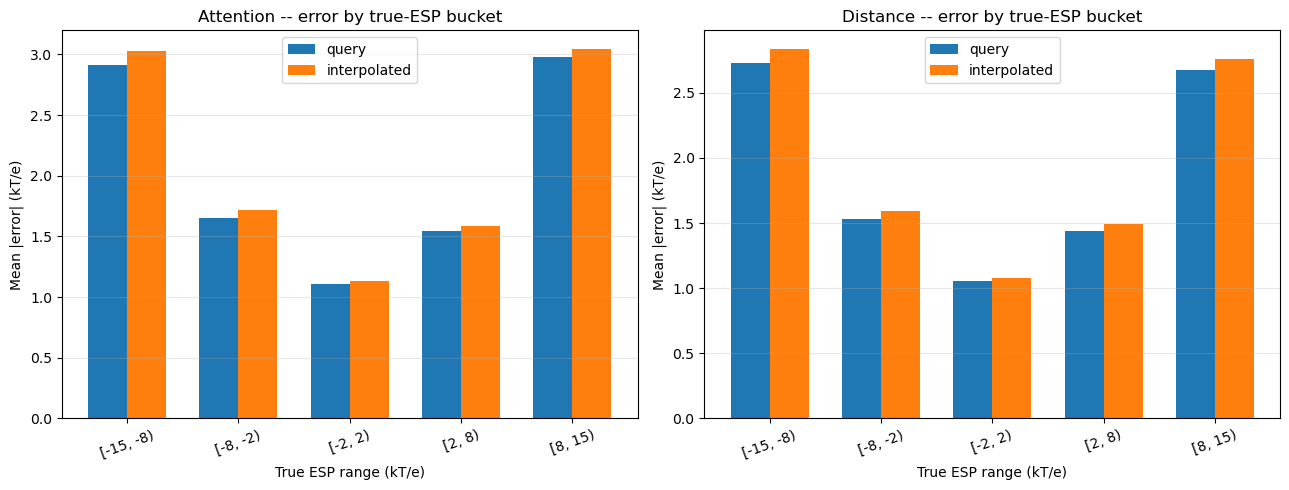

,model,population,range,n_vertices,mean_abs_error_kT_e,median_abs_error_kT_e
0,attention,interpolated,"[-15, -8)",1985756,3.027043,2.866591
1,attention,query,"[-15, -8)",104099,2.912039,2.733336
2,attention,interpolated,"[-2, 2)",22355316,1.128846,0.877595
3,attention,query,"[-2, 2)",1186248,1.111612,0.854352
4,attention,interpolated,"[-8, -2)",16620903,1.715347,1.338765
5,attention,query,"[-8, -2)",891734,1.654745,1.266758
6,attention,interpolated,"[2, 8)",12324015,1.588223,1.290087
7,attention,query,"[2, 8)",625456,1.544116,1.233202
8,attention,interpolated,"[8, 15)",1196313,3.046666,2.791754
9,attention,query,"[8, 15)",60080,2.980394,2.703325


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, model in zip(axes, ["attention", "distance"]):
    sub = buckets[buckets["model"] == model]
    x = np.arange(len(RANGE_ORDER))
    width = 0.35
    for i, pop in enumerate(["query", "interpolated"]):
        pop_sub = sub[sub["population"] == pop].set_index("range").reindex(RANGE_ORDER)
        ax.bar(x + (i - 0.5) * width, pop_sub["mean_abs_error_kT_e"], width=width, label=pop)
    ax.set_xticks(x)
    ax.set_xticklabels(RANGE_ORDER, rotation=20)
    ax.set_xlabel("True ESP range (kT/e)")
    ax.set_ylabel("Mean |error| (kT/e)")
    ax.set_title(f"{model.capitalize()} -- error by true-ESP bucket")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(buckets.sort_values(["model", "range", "population"]).reset_index(drop=True))


---
## 3. Query vs. Interpolated -- Protein-Level Comparison

Is the model's direct prediction at query nodes meaningfully more accurate
than the RBF-interpolated reconstruction at the rest of the mesh?

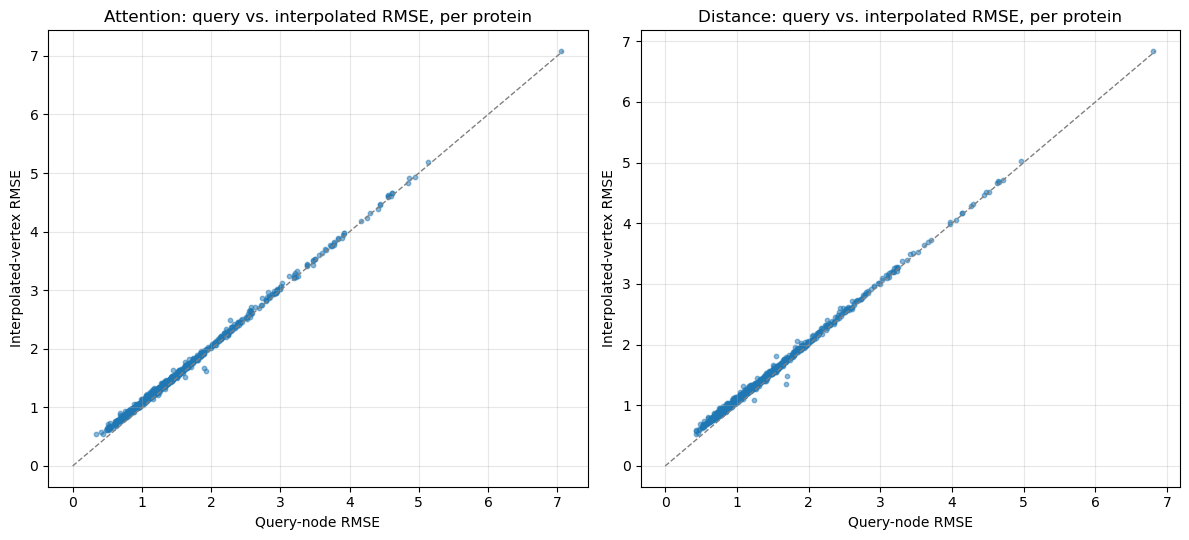

attention: interpolated RMSE is higher than query RMSE for 97.4% of test proteins (mean diff = +0.0701 kT/e)
distance: interpolated RMSE is higher than query RMSE for 98.3% of test proteins (mean diff = +0.0795 kT/e)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, prefix in zip(axes, ["attention", "distance"]):
    x, y = df_test[f"{prefix}_query_rmse"], df_test[f"{prefix}_interpolated_rmse"]
    ax.scatter(x, y, s=10, alpha=0.5)
    lims = [0, max(x.max(), y.max())]
    ax.plot(lims, lims, "--", color="gray", lw=1)
    ax.set_xlabel("Query-node RMSE")
    ax.set_ylabel("Interpolated-vertex RMSE")
    ax.set_title(f"{prefix.capitalize()}: query vs. interpolated RMSE, per protein")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for prefix in ("attention", "distance"):
    diff = df_test[f"{prefix}_interpolated_rmse"] - df_test[f"{prefix}_query_rmse"]
    frac_worse = (diff > 0).mean()
    print(f"{prefix}: interpolated RMSE is higher than query RMSE for "
          f"{frac_worse:.1%} of test proteins (mean diff = {diff.mean():+.4f} kT/e)")


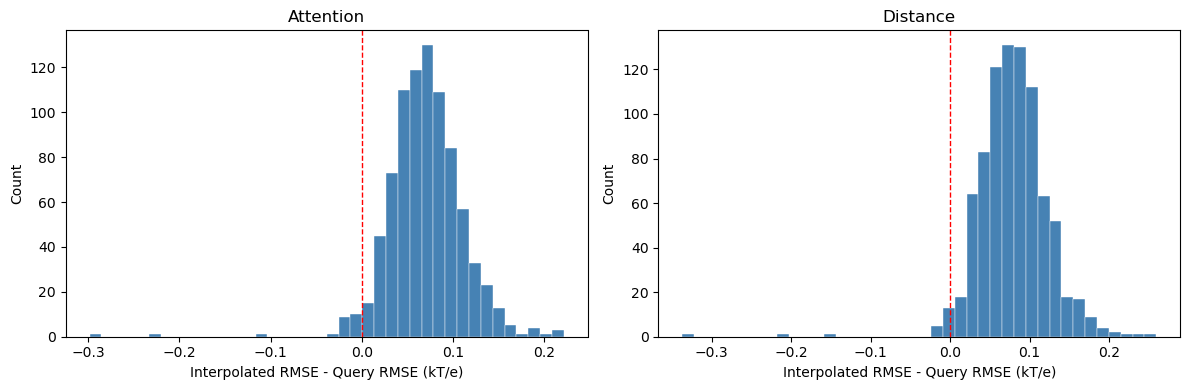

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, prefix in zip(axes, ["attention", "distance"]):
    diff = df_test[f"{prefix}_interpolated_rmse"] - df_test[f"{prefix}_query_rmse"]
    ax.hist(diff, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_xlabel("Interpolated RMSE - Query RMSE (kT/e)")
    ax.set_ylabel("Count")
    ax.set_title(f"{prefix.capitalize()}")
plt.tight_layout()
plt.show()


---
## 4. Hotspot vs. Diffuse -- Dataset-Wide

Using the *existing* query-level `attention_morans_i`/`distance_morans_i`
(already in the master CSV -- zero new computation) against
`whole_mesh_rmse`: which high-error proteins look spatially clustered
("hotspot") vs. spatially diffuse?

Note: the illustrative examples in the next section use *full-mesh* Moran's
I (computed by `compute_vertex_error_stats.py`'s phase 3 on the entire
reconstructed surface), which reads systematically higher than this
query-level version — the RBF-smoothed interpolated region is, by
construction, spatially smoother than the sparse query-node error field.
Not a contradiction, just two different resolutions of the same idea.

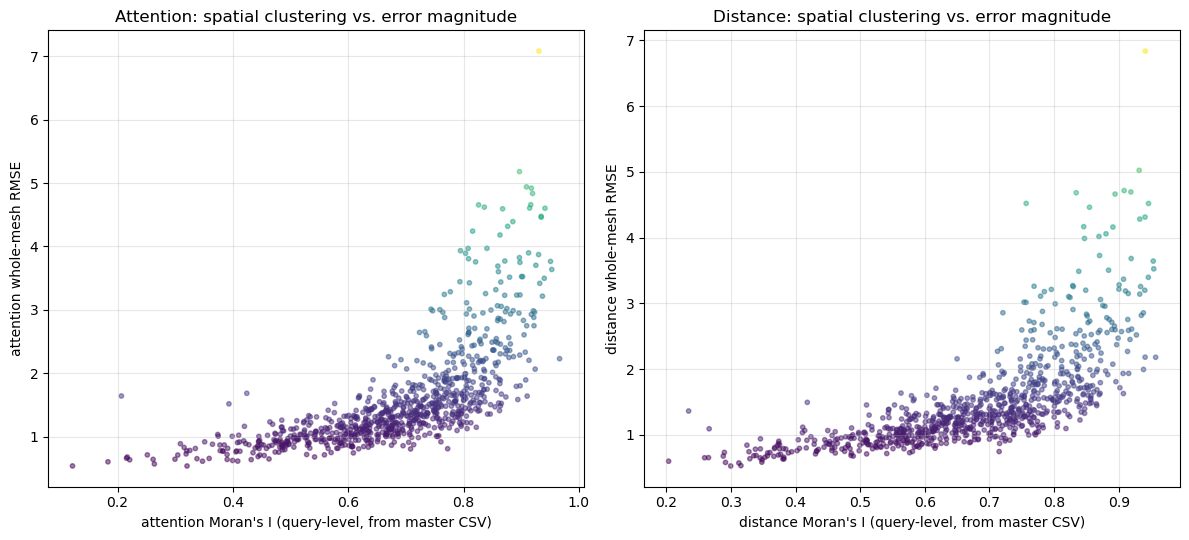

attention: Spearman r(morans_i, whole_mesh_rmse) = 0.832  (p=5.02e-219)
distance: Spearman r(morans_i, whole_mesh_rmse) = 0.831  (p=3.13e-217)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, prefix in zip(axes, ["attention", "distance"]):
    sc = ax.scatter(df_test[f"{prefix}_morans_i"], df_test[f"{prefix}_whole_mesh_rmse"],
                     s=10, alpha=0.5, c=df_test[f"{prefix}_whole_mesh_rmse"], cmap="viridis")
    ax.set_xlabel(f"{prefix} Moran's I (query-level, from master CSV)")
    ax.set_ylabel(f"{prefix} whole-mesh RMSE")
    ax.set_title(f"{prefix.capitalize()}: spatial clustering vs. error magnitude")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for prefix in ("attention", "distance"):
    r, p = spearmanr(df_test[f"{prefix}_morans_i"], df_test[f"{prefix}_whole_mesh_rmse"])
    print(f"{prefix}: Spearman r(morans_i, whole_mesh_rmse) = {r:.3f}  (p={p:.2e})")


---
## 5. Illustrative Examples -- Hotspot vs. Diffuse, Spatially

Static per-vertex scatter (colored by |error|) for a small set of
representative proteins selected by `compute_vertex_error_stats.py`'s
phase 3: worst overall RMSE, highest full-mesh Moran's I ("hotspot"), and
lowest full-mesh Moran's I ("diffuse"). Large examples are subsampled for
legible rendering.

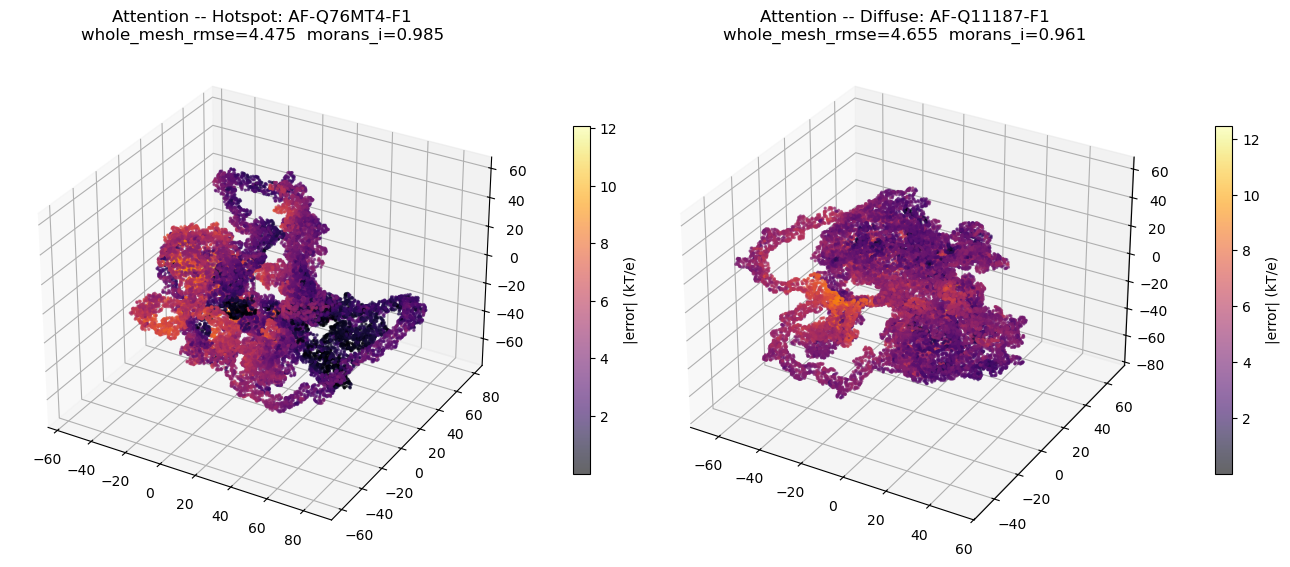

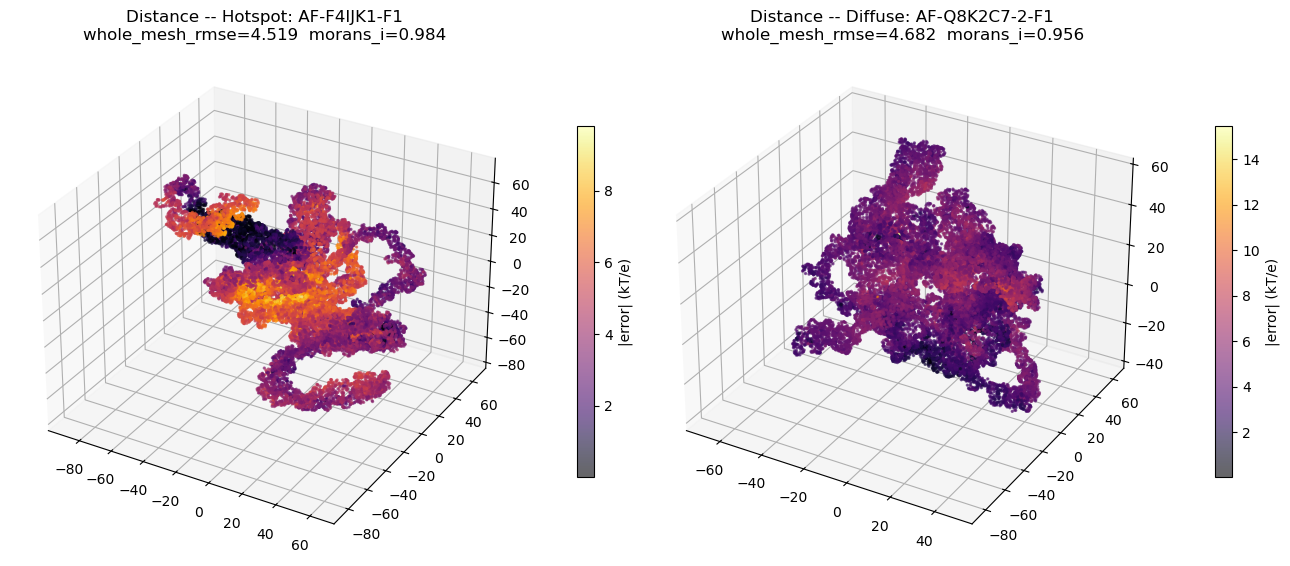

In [8]:
MAX_POINTS = 25_000
RNG = np.random.default_rng(42)

def _load_example(row):
    npz = np.load(Path("/home/student/thesis/outputs/vertex_examples") / row["npz_filename"])
    pos, err = npz["position"], npz["error"]
    if len(pos) > MAX_POINTS:
        idx = RNG.choice(len(pos), MAX_POINTS, replace=False)
        pos, err = pos[idx], err[idx]
    return pos, err

for model in ["attention", "distance"]:
    model_examples = examples_index[examples_index["model"] == model]
    hotspot_rows = model_examples[model_examples["selection_reason"] == "hotspot_high_morans_i"]
    diffuse_rows = model_examples[model_examples["selection_reason"] == "diffuse_low_morans_i"]
    if hotspot_rows.empty or diffuse_rows.empty:
        print(f"{model}: no hotspot/diffuse pair available (small candidate pool?)")
        continue
    hotspot_row, diffuse_row = hotspot_rows.iloc[0], diffuse_rows.iloc[0]

    fig = plt.figure(figsize=(13, 6))
    for i, (row, label) in enumerate([(hotspot_row, "Hotspot"), (diffuse_row, "Diffuse")]):
        pos, err = _load_example(row)
        ax = fig.add_subplot(1, 2, i + 1, projection="3d")
        sc = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=np.abs(err), cmap="inferno", s=2, alpha=0.6)
        ax.set_title(f"{model.capitalize()} -- {label}: {row['protein_id']}\n"
                     f"whole_mesh_rmse={row['whole_mesh_rmse']:.3f}  morans_i={row['morans_i_full_mesh']:.3f}")
        fig.colorbar(sc, ax=ax, label="|error| (kT/e)", fraction=0.03, pad=0.1)
    plt.tight_layout()
    plt.show()


---
## 6. Size-Bucketed Error Breakdown

Protein-level RMSE/Pearson r (already in `master`, same as
`error_clustering_analysis.ipynb`), bucketed into 100-residue bins across
the 848 test proteins — does error climb steadily with sequence length, or
does one specific size range struggle disproportionately more than a smooth
trend would predict?

In [9]:
BIN_WIDTH = 100
n_bins = int(np.ceil((df_test["sequence_length"].max() + 1) / BIN_WIDTH))
edges = [i * BIN_WIDTH for i in range(n_bins + 1)]
bucket_labels = [f"{edges[i]}-{edges[i+1]}" for i in range(len(edges) - 1)]
df_test["size_bucket"] = pd.cut(df_test["sequence_length"], bins=edges, labels=bucket_labels,
                                 right=False, include_lowest=True)

size_bucket_table = df_test.groupby("size_bucket", observed=True).agg(
    n=("protein_id", "count"),
    attention_rmse=("attention_rmse", "mean"),
    attention_pearson_r=("attention_pearson_r", "mean"),
    distance_rmse=("distance_rmse", "mean"),
    distance_pearson_r=("distance_pearson_r", "mean"),
).round(4)
print(f"{size_bucket_table['n'].sum()} proteins across {len(size_bucket_table)} buckets of {BIN_WIDTH} aa "
      f"(sequence_length range: {df_test['sequence_length'].min()}-{df_test['sequence_length'].max()} aa)")
display(size_bucket_table)


848 proteins across 10 buckets of 100 aa (sequence_length range: 22-999 aa)


,n,attention_rmse,attention_pearson_r,distance_rmse,distance_pearson_r
size_bucket,,,,,
0-100,62,0.7675,0.9589,0.7081,0.9628
100-200,132,1.0676,0.9490,1.0033,0.9550
200-300,144,1.2097,0.9435,1.1675,0.9470
300-400,124,1.3824,0.9361,1.3074,0.9382
400-500,88,1.6350,0.9258,1.5889,0.9280
500-600,81,1.7118,0.9324,1.6034,0.9351
600-700,75,1.9848,0.9228,1.8260,0.9288
700-800,51,2.2687,0.9092,2.0998,0.9119
800-900,41,2.0495,0.9133,1.9558,0.9156


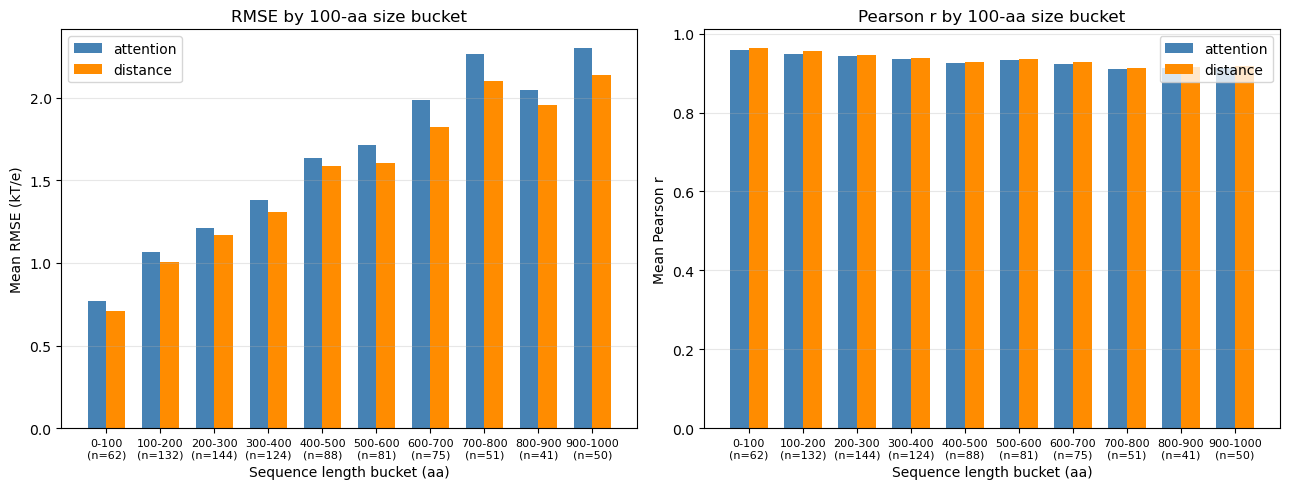

attention: RMSE increases in 8/9 consecutive bucket-to-bucket steps (89% monotonic)
  best bucket:  0-100      RMSE=0.7675
  worst bucket: 900-1000   RMSE=2.3001  (3.00x the best bucket)
distance: RMSE increases in 8/9 consecutive bucket-to-bucket steps (89% monotonic)
  best bucket:  0-100      RMSE=0.7081
  worst bucket: 900-1000   RMSE=2.1393  (3.02x the best bucket)


In [10]:
x = np.arange(len(size_bucket_table))
width = 0.35
x_labels = [f"{idx}\n(n={n})" for idx, n in zip(size_bucket_table.index, size_bucket_table["n"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel, title in [
    (axes[0], "rmse", "Mean RMSE (kT/e)", "RMSE by 100-aa size bucket"),
    (axes[1], "pearson_r", "Mean Pearson r", "Pearson r by 100-aa size bucket"),
]:
    ax.bar(x - width / 2, size_bucket_table[f"attention_{metric}"], width, label="attention", color="steelblue")
    ax.bar(x + width / 2, size_bucket_table[f"distance_{metric}"], width, label="distance", color="darkorange")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_xlabel("Sequence length bucket (aa)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

for prefix in ("attention", "distance"):
    rmse_col = f"{prefix}_rmse"
    steps_up = (size_bucket_table[rmse_col].diff().dropna() > 0).sum()
    n_steps  = len(size_bucket_table) - 1
    worst_bucket = size_bucket_table[rmse_col].idxmax()
    best_bucket  = size_bucket_table[rmse_col].idxmin()
    print(f"{prefix}: RMSE increases in {steps_up}/{n_steps} consecutive bucket-to-bucket steps "
          f"({steps_up/n_steps:.0%} monotonic)")
    print(f"  best bucket:  {best_bucket:<10} RMSE={size_bucket_table.loc[best_bucket, rmse_col]:.4f}")
    print(f"  worst bucket: {worst_bucket:<10} RMSE={size_bucket_table.loc[worst_bucket, rmse_col]:.4f}  "
          f"({size_bucket_table.loc[worst_bucket, rmse_col] / size_bucket_table.loc[best_bucket, rmse_col]:.2f}x the best bucket)")


---
## 7. Summary

*Fill in after reviewing the plots and tables above:*

- **Does error concentrate at extreme ESP values, or in the middle?**
  (Section 2's bucket table.)
- **Is direct prediction meaningfully better than interpolation**, and
  does that gap change across the ESP range? (Sections 2-3.)
- **Do high-error proteins tend to be hotspot-y or diffuse?** (Section 4.)
- **Does the visual character of the illustrated hotspot/diffuse examples
  match the dataset-wide Moran's I story?** (Section 5.)
- **Is the sequence-length effect a smooth trend or bucket-specific**
  (Section 6)? Cross-reference against the same breakdown in
  `error_clustering_analysis.ipynb` §12 — same underlying `sequence_length`
  and error columns, so the two should agree exactly.

**Candidate follow-ups:**
- Cross-reference the hotspot/diffuse classification with the protein-level
  clusters from `error_clustering_analysis.ipynb` — do hotspot proteins
  cluster together on structural properties?
- The deferred AlphaFold-structural-uncertainty notebook.